In [1]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

folder = "/content/drive/MyDrive/Semicon_Hackathon"

print(os.listdir(folder))

['model.pth.zip', 'Test_NoisyLR.zip', 'train.zip', '01_Dataset_Analysis_ipynb.ipynb', '02_Preprocessing_ipynb.ipynb', '03_Baseline_Validation.ipynb']


In [5]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Semicon_Hackathon/train.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted!")

✅ Dataset extracted!


In [6]:
print(os.listdir("/content/dataset"))
print(os.listdir("/content/dataset/train"))

['train', '__MACOSX']
['GT', '.DS_Store', 'NoisyLR']


In [7]:
gt_path = "/content/dataset/train/GT"
lr_path = "/content/dataset/train/NoisyLR"

print("GT images:", len([f for f in os.listdir(gt_path) if f.endswith(".npy")]))
print("Noisy LR images:", len([f for f in os.listdir(lr_path) if f.endswith(".npy")]))

GT images: 3200
Noisy LR images: 3200


In [8]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader


class SEMDataset(Dataset):

    def __init__(self, root):
        self.gt_path = os.path.join(root, "GT")
        self.lr_path = os.path.join(root, "NoisyLR")

        self.files = sorted([
            f for f in os.listdir(self.gt_path)
            if f.endswith(".npy")
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        filename = self.files[idx]

        gt = np.load(os.path.join(self.gt_path, filename))
        lr = np.load(os.path.join(self.lr_path, filename))

        gt = torch.from_numpy(gt).unsqueeze(0).float()
        lr = torch.from_numpy(lr).unsqueeze(0).float()

        return lr, gt

In [9]:
dataset = SEMDataset("/content/dataset/train")

print("Total images:", len(dataset))

Total images: 3200


In [10]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("DataLoader ready")

DataLoader ready


In [11]:
lr_batch, gt_batch = next(iter(train_loader))

print("LR batch:", lr_batch.shape)
print("GT batch:", gt_batch.shape)

LR batch: torch.Size([16, 1, 128, 128])
GT batch: torch.Size([16, 1, 256, 256])


In [12]:
import torch.nn as nn


class SRCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.upsample = nn.Upsample(
            scale_factor=2,
            mode="bicubic",
            align_corners=False
        )

        self.conv1 = nn.Conv2d(
            1, 64,
            kernel_size=9,
            padding=4
        )

        self.conv2 = nn.Conv2d(
            64, 32,
            kernel_size=5,
            padding=2
        )

        self.conv3 = nn.Conv2d(
            32, 1,
            kernel_size=5,
            padding=2
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):

        x = self.upsample(x)

        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.conv3(x)

        return x

In [13]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = SRCNN().to(device)

print("Device:", device)
print(model)

Device: cuda
SRCNN(
  (upsample): Upsample(scale_factor=2.0, mode='bicubic')
  (conv1): Conv2d(1, 64, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4))
  (conv2): Conv2d(64, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv3): Conv2d(32, 1, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu): ReLU(inplace=True)
)


In [14]:
lr_batch, gt_batch = next(iter(train_loader))

lr_batch = lr_batch.to(device)
gt_batch = gt_batch.to(device)

with torch.no_grad():
    output = model(lr_batch)

print("Input LR :", lr_batch.shape)
print("Model output:", output.shape)
print("GT        :", gt_batch.shape)

Input LR : torch.Size([16, 1, 128, 128])
Model output: torch.Size([16, 1, 256, 256])
GT        : torch.Size([16, 1, 256, 256])


In [15]:
import torch.optim as optim

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

print("Loss:", criterion)
print("Optimizer:", optimizer)

Loss: MSELoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


In [16]:
epochs = 10

for epoch in range(epochs):

    model.train()
    running_loss = 0.0

    for lr, gt in train_loader:

        lr = lr.to(device, non_blocking=True)
        gt = gt.to(device, non_blocking=True)

        optimizer.zero_grad()

        pred = model(lr)

        loss = criterion(pred, gt)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    print(f"Epoch {epoch+1}/{epochs}  Loss: {avg_loss:.6f}")

Epoch 1/10  Loss: 0.012519
Epoch 2/10  Loss: 0.003684
Epoch 3/10  Loss: 0.003549
Epoch 4/10  Loss: 0.003488
Epoch 5/10  Loss: 0.003449
Epoch 6/10  Loss: 0.003418
Epoch 7/10  Loss: 0.003399
Epoch 8/10  Loss: 0.003379
Epoch 9/10  Loss: 0.003362
Epoch 10/10  Loss: 0.003350


In [17]:
torch.save(model.state_dict(), "SRCNN_Baseline.pth")

print("✅ Model saved")

✅ Model saved


In [18]:
!cp SRCNN_Baseline.pth /content/drive/MyDrive/Semicon_Hackathon/

In [19]:
import os

model_path = "/content/drive/MyDrive/Semicon_Hackathon/SRCNN_Baseline.pth"

print("Exists:", os.path.exists(model_path))
print("Size (MB):", os.path.getsize(model_path) / (1024 * 1024))

Exists: True
Size (MB): 0.22159671783447266


In [20]:
!pip -q install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 27.1 MB/s eta 0:00:00


In [21]:
from torchmetrics.image import PeakSignalNoiseRatio
from torchmetrics.image import StructuralSimilarityIndexMeasure

psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device)
ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

model.eval()

total_psnr = 0
total_ssim = 0
count = 0

with torch.no_grad():

    for lr, gt in train_loader:

        lr = lr.to(device)
        gt = gt.to(device)

        pred = model(lr)

        total_psnr += psnr_metric(pred, gt).item()
        total_ssim += ssim_metric(pred, gt).item()

        count += 1

print("Average PSNR:", total_psnr / count)
print("Average SSIM:", total_ssim / count)

Average PSNR: 25.18510545730591
Average SSIM: 0.7126769438385964


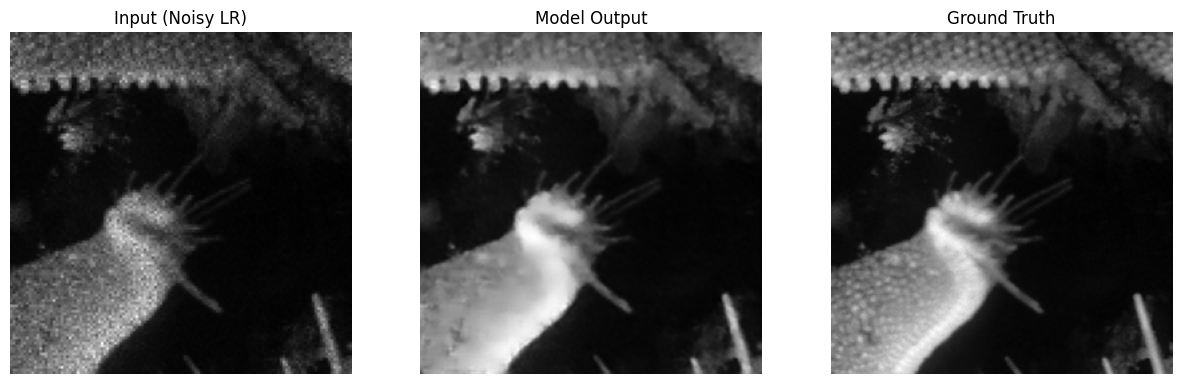

In [22]:
import matplotlib.pyplot as plt

model.eval()

lr, gt = dataset[0]

with torch.no_grad():
    pred = model(
        lr.unsqueeze(0).to(device)
    ).cpu().squeeze().numpy()

lr = lr.squeeze().numpy()
gt = gt.squeeze().numpy()

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(lr, cmap="gray")
plt.title("Input (Noisy LR)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(pred, cmap="gray")
plt.title("Model Output")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gt, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.show()

In [23]:
import os

drive_folder = "/content/drive/MyDrive/Semicon_Hackathon"

print(os.listdir(drive_folder))

['model.pth.zip', 'Test_NoisyLR.zip', 'train.zip', '01_Dataset_Analysis_ipynb.ipynb', '02_Preprocessing_ipynb.ipynb', '03_Baseline_Validation.ipynb', 'SRCNN_Baseline.pth']


In [24]:
import zipfile
import os

test_zip = "/content/drive/MyDrive/Semicon_Hackathon/Test_NoisyLR.zip"
test_extract = "/content/test_dataset"

with zipfile.ZipFile(test_zip, "r") as zip_ref:
    zip_ref.extractall(test_extract)

print("✅ Test dataset extracted!")

✅ Test dataset extracted!


In [25]:
for root, dirs, files in os.walk("/content/test_dataset"):
    print("Folder:", root)
    print("Number of files:", len(files))
    print("First few:", files[:5])
    print()

Folder: /content/test_dataset
Number of files: 0
First few: []

Folder: /content/test_dataset/__MACOSX
Number of files: 1
First few: ['._NoisyLR']

Folder: /content/test_dataset/__MACOSX/NoisyLR
Number of files: 400
First few: ['._000171.npy', '._000329.npy', '._000214.npy', '._000359.npy', '._000176.npy']

Folder: /content/test_dataset/NoisyLR
Number of files: 400
First few: ['000170.npy', '000028.npy', '000301.npy', '000187.npy', '000224.npy']



In [26]:
import torch
import torch.nn as nn
import numpy as np
import os
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [27]:
class SRCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.upsample = nn.Upsample(
            scale_factor=2,
            mode="bicubic",
            align_corners=False
        )

        self.net = nn.Sequential(
            nn.Conv2d(1, 64, 9, padding=4),
            nn.ReLU(True),

            nn.Conv2d(64, 32, 5, padding=2),
            nn.ReLU(True),

            nn.Conv2d(32, 1, 5, padding=2)
        )

    def forward(self, x):
        x = self.upsample(x)
        x = self.net(x)
        return x

In [29]:
class SRCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.upsample = nn.Upsample(
            scale_factor=2,
            mode="bicubic",
            align_corners=False
        )

        self.net = nn.Sequential(
            nn.Conv2d(1,64,9,padding=4),
            nn.ReLU(True),

            nn.Conv2d(64,32,5,padding=2),
            nn.ReLU(True),

            nn.Conv2d(32,1,5,padding=2)
        )

    def forward(self,x):
        x=self.upsample(x)
        x=self.net(x)
        return x

In [30]:
import torch
import torch.nn as nn

class SRCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.upsample = nn.Upsample(
            scale_factor=2,
            mode="bicubic",
            align_corners=False
        )

        self.net = nn.Sequential(
            nn.Conv2d(1, 64, 9, padding=4),
            nn.ReLU(True),

            nn.Conv2d(64, 32, 5, padding=2),
            nn.ReLU(True),

            nn.Conv2d(32, 1, 5, padding=2)
        )

    def forward(self, x):
        x = self.upsample(x)
        x = self.net(x)
        return x

In [31]:
model_path = "/content/drive/MyDrive/Semicon_Hackathon/SRCNN_Baseline.pth"

model = SRCNN().to(device)

checkpoint = torch.load(
    model_path,
    map_location=device
)

print(type(checkpoint))
print(checkpoint.keys())

<class 'collections.OrderedDict'>
odict_keys(['conv1.weight', 'conv1.bias', 'conv2.weight', 'conv2.bias', 'conv3.weight', 'conv3.bias'])


In [32]:
import torch
import torch.nn as nn

class SRCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.upsample = nn.Upsample(
            scale_factor=2,
            mode="bicubic",
            align_corners=False
        )

        self.conv1 = nn.Conv2d(1, 64, 9, padding=4)
        self.conv2 = nn.Conv2d(64, 32, 5, padding=2)
        self.conv3 = nn.Conv2d(32, 1, 5, padding=2)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.upsample(x)

        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.conv3(x)

        return x

In [33]:
model_path = "/content/drive/MyDrive/Semicon_Hackathon/SRCNN_Baseline.pth"

model = SRCNN().to(device)

model.load_state_dict(
    torch.load(model_path, map_location=device)
)

model.eval()

print("✅ SRCNN model loaded successfully!")

✅ SRCNN model loaded successfully!


In [34]:
test_path = "/content/test_dataset/NoisyLR"

test_files = sorted([
    f for f in os.listdir(test_path)
    if f.endswith(".npy") and not f.startswith("._")
])

print("Total test images:", len(test_files))
print("First 5:", test_files[:5])

Total test images: 400
First 5: ['000000.npy', '000001.npy', '000002.npy', '000003.npy', '000004.npy']


In [35]:
filename = test_files[0]

lr = np.load(
    os.path.join(test_path, filename)
).astype(np.float32)

print("Input shape:", lr.shape)
print("Input range:", lr.min(), "to", lr.max())

Input shape: (128, 128)
Input range: 0.0010295246 to 1.5406137


In [36]:
lr_tensor = torch.from_numpy(lr).unsqueeze(0).unsqueeze(0).to(device)

with torch.no_grad():
    prediction = model(lr_tensor)

prediction = prediction.squeeze().cpu().numpy()

print("Output shape:", prediction.shape)
print("Output range:", prediction.min(), "to", prediction.max())

Output shape: (256, 256)
Output range: 0.01771955 to 1.1021234


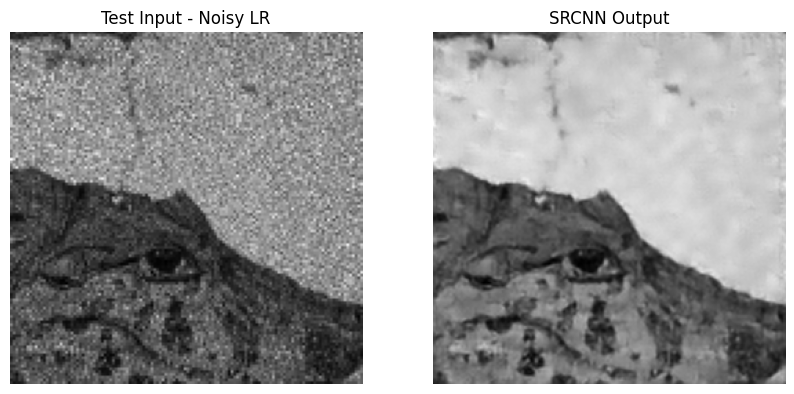

In [37]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(lr, cmap="gray")
plt.title("Test Input - Noisy LR")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(prediction, cmap="gray")
plt.title("SRCNN Output")
plt.axis("off")

plt.show()

In [38]:
import os
import numpy as np
import torch

output_dir = "/content/test_predictions"
os.makedirs(output_dir, exist_ok=True)

model.eval()

with torch.no_grad():

    for i, filename in enumerate(test_files):

        # Load noisy LR image
        lr = np.load(
            os.path.join(test_path, filename)
        ).astype(np.float32)

        # Convert to tensor
        lr_tensor = (
            torch.from_numpy(lr)
            .unsqueeze(0)
            .unsqueeze(0)
            .to(device)
        )

        # SRCNN prediction
        prediction = model(lr_tensor)

        # Convert back to NumPy
        prediction = prediction.squeeze().cpu().numpy()

        # Save prediction
        output_filename = filename.replace(".npy", "_SR.npy")

        np.save(
            os.path.join(output_dir, output_filename),
            prediction
        )

        if (i + 1) % 50 == 0:
            print(f"Processed {i + 1}/{len(test_files)}")

print("✅ All test images processed!")
print("Saved to:", output_dir)

Processed 50/400
Processed 100/400
Processed 150/400
Processed 200/400
Processed 250/400
Processed 300/400
Processed 350/400
Processed 400/400
✅ All test images processed!
Saved to: /content/test_predictions


In [39]:
print("Number of predictions:",
      len(os.listdir(output_dir)))

print("First 5 predictions:")
print(sorted(os.listdir(output_dir))[:5])

Number of predictions: 400
First 5 predictions:
['000000_SR.npy', '000001_SR.npy', '000002_SR.npy', '000003_SR.npy', '000004_SR.npy']


In [40]:
import os
import shutil

drive_output = "/content/drive/MyDrive/Semicon_Hackathon/test_predictions"

os.makedirs(drive_output, exist_ok=True)

for filename in os.listdir(output_dir):
    shutil.copy2(
        os.path.join(output_dir, filename),
        os.path.join(drive_output, filename)
    )

print("✅ Predictions copied to Drive!")
print("Location:", drive_output)
print("Total files:", len(os.listdir(drive_output)))

✅ Predictions copied to Drive!
Location: /content/drive/MyDrive/Semicon_Hackathon/test_predictions
Total files: 400


In [41]:
import shutil

zip_output = "/content/drive/MyDrive/Semicon_Hackathon/test_predictions"

shutil.make_archive(
    zip_output,
    "zip",
    output_dir
)

print("✅ ZIP created!")
print(zip_output + ".zip")

✅ ZIP created!
/content/drive/MyDrive/Semicon_Hackathon/test_predictions.zip


In [42]:
import os

zip_file = "/content/drive/MyDrive/Semicon_Hackathon/test_predictions.zip"

print("ZIP exists:", os.path.exists(zip_file))

if os.path.exists(zip_file):
    size_mb = os.path.getsize(zip_file) / (1024 * 1024)
    print(f"ZIP size: {size_mb:.2f} MB")

ZIP exists: True
ZIP size: 87.25 MB
